# Quantum Fourier Transform & Quantum Phase Estimation
## From Matrix Formula to Circuit Gates to Eigenvalue Finding

This notebook develops the QFT and QPE in four stages:

| Section | Topic |
|:--------|:------|
| 1 | Background & Key Equations |
| 2 | Imports & Shared Utilities |
| 3 | Analytic QFT Matrix |
| 4 | Object-Oriented QFT / IQFT |
| 5 | Gate-Circuit QFT / IQFT |
| 6 | Pauli Decomposition of 4×4 Matrices |
| 7 | Quantum Phase Estimation Algorithm |
| 8 | QPE Example: Eigenvalues of a 4×4 Hamiltonian |
| 9 | Summary & Key Formulae |

At the end of this notebook, you will also find a detailed comparison between the VQE and the QPE for the Lipkin model of project 1.


---
## 1. Background & Key Equations

### 1.1 Quantum Fourier Transform

The QFT on $n$ qubits maps computational basis states as:

$$|j\rangle \xrightarrow{\text{QFT}} \frac{1}{\sqrt{2^n}}
\sum_{k=0}^{2^n-1} e^{2\pi i jk/2^n}|k\rangle$$

The full matrix is $F_{jk} = \omega^{jk}/\sqrt{2^n}$ where $\omega = e^{2\pi i/2^n}$.

### 1.2 Circuit Decomposition

On a quantum computer the QFT is built from:

- **Hadamard gate**: $H = \frac{1}{\sqrt{2}}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$
- **Phase-rotation gates**: $R_k = \begin{pmatrix}1&0\\0&e^{2\pi i/2^k}\end{pmatrix}$
- **SWAP gates** for bit-reversal at the end

For qubit $j$, the circuit layer is:

$$H_j \;\cdot\; CR_2(j{+}1,j) \;\cdot\; CR_3(j{+}2,j) \;\cdots$$

Gate count: $n$ Hadamards $+$ $n(n{-}1)/2$ controlled-$R_k$ $+$ $\lfloor n/2 \rfloor$ SWAPs.

The **IQFT** reverses the circuit and replaces each $R_k \to R_k^\dagger = R_k^*$.

### 1.3 Pauli Decomposition

Any $2^n \times 2^n$ Hermitian matrix can be written in the Pauli basis
$\{I,X,Y,Z\}^{\otimes n}$:

$$H = \sum_{P \in \{I,X,Y,Z\}^{\otimes n}} c_P \cdot P, \qquad
c_P = \frac{\text{Tr}(P^\dagger H)}{2^n}$$

### 1.4 Quantum Phase Estimation

Given a unitary $U$ with eigenvalue equation $U|\psi\rangle = e^{2\pi i\varphi}|\psi\rangle$
($\varphi \in [0,1)$), QPE estimates $\varphi$ to $t$ bits:

$$|0\rangle^{\otimes t}|\psi\rangle
\xrightarrow{H^{\otimes t}}
\xrightarrow{\text{c-}U^{2^k}}
\xrightarrow{\text{IQFT}_t^\dagger}
\approx |\tilde{j}\rangle|\psi\rangle, \quad
\varphi \approx \frac{\tilde{j}}{2^t}$$

**Precision**: $|\varphi - \tilde{j}/2^t| \leq 1/2^t$

**Eigenvalue recovery**: For $U = e^{iHt_0}$, the eigenvalue of $H$ is
$\lambda_k = 2\pi\varphi_k / t_0$. For negative eigenvalues: if $\varphi > 0.5$
then $\lambda = 2\pi(\varphi - 1)/t_0$.


---
## 2. Imports & Shared Utilities

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import product as iproduct
from scipy.linalg import eigh

# ── Colour palette ─────────────────────────────────────────────────
BG, PANEL  = "#0d0f1a", "#131629"
ACCENT     = "#4fc3f7"
WARM       = "#ff7043"
GREEN      = "#69f0ae"
PURPLE     = "#ce93d8"
GRID       = "#1e2340"
TEXT       = "#e8eaf6"
PINK       = "#f48fb1"

def dark_style():
    plt.rcParams.update({
        'figure.facecolor': BG,    'axes.facecolor':  PANEL,
        'axes.edgecolor':   GRID,  'axes.labelcolor': TEXT,
        'xtick.color':      TEXT,  'ytick.color':     TEXT,
        'text.color':       TEXT,  'grid.color':      GRID,
        'grid.linewidth':   0.6,   'legend.facecolor':PANEL,
        'legend.edgecolor': GRID,
    })

dark_style()
print("Imports OK — NumPy", np.__version__)


Imports OK — NumPy 1.22.3


---
## 3. Analytic QFT Matrix

The closed-form matrix $F_{jk} = e^{2\pi i jk/2^n}/\sqrt{2^n}$ from `qft.py`.


In [2]:
def analytic_qft(n):
    """Closed-form QFT matrix: F[j,k] = omega^(jk) / sqrt(2^n)."""
    dim   = 2 ** n
    omega = np.exp(2j * np.pi / dim)
    idx   = np.arange(dim)
    return np.power(omega, np.outer(idx, idx)) / np.sqrt(dim)

def analytic_iqft(n):
    """Closed-form IQFT = QFT†."""
    return analytic_qft(n).conj()

# Test on n=4
n = 4
F  = analytic_qft(n)
Fd = analytic_iqft(n)

print(f"QFT shape:              {F.shape}")
print(f"Max |F·F† − I|:         {np.max(np.abs(F @ Fd - np.eye(2**n))):.3e}")
print(f"Max |IQFT − QFT†|:      {np.max(np.abs(Fd - F.conj().T)):.3e}")
print(f"All |F_jk| = 1/√{2**n}:  {np.allclose(np.abs(F), 1/np.sqrt(2**n))}")


QFT shape:              (16, 16)
Max |F·F† − I|:         1.841e-15
Max |IQFT − QFT†|:      0.000e+00
All |F_jk| = 1/√16:  True


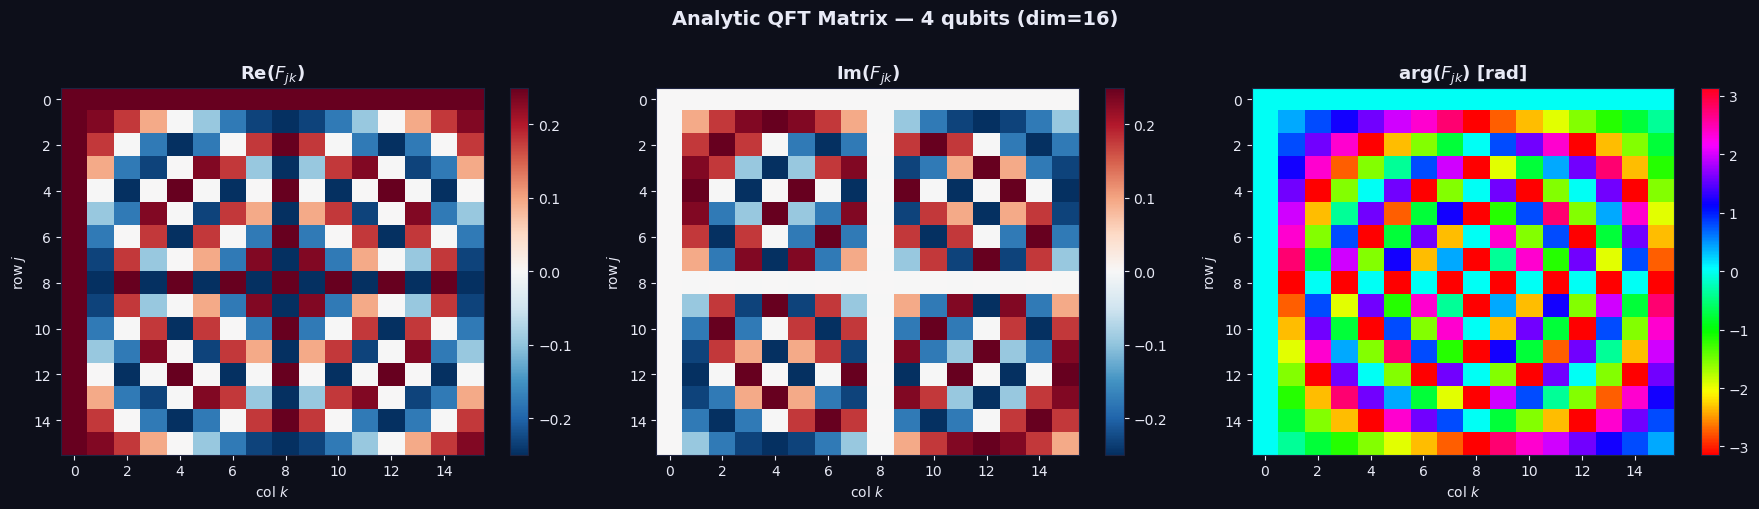

In [3]:
# Visualise QFT matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
n_vis = 4; F_vis = analytic_qft(n_vis)
for ax_i, (data, cmap, title) in zip(axes, [
    (F_vis.real,       'RdBu_r', 'Re($F_{jk}$)'),
    (F_vis.imag,       'RdBu_r', 'Im($F_{jk}$)'),
    (np.angle(F_vis),  'hsv',    'arg($F_{jk}$) [rad]'),
]):
    vabs = max(np.abs(data).max(), 1e-16)
    im = ax_i.imshow(data, cmap=cmap, vmin=-vabs, vmax=vabs,
                     interpolation='nearest', aspect='auto')
    plt.colorbar(im, ax=ax_i)
    ax_i.set_title(title, fontweight='bold', color=TEXT, fontsize=13)
    ax_i.set_xlabel('col $k$'); ax_i.set_ylabel('row $j$')
plt.suptitle(f'Analytic QFT Matrix — {n_vis} qubits (dim={2**n_vis})',
             fontsize=14, fontweight='bold', color=TEXT, y=1.01)
plt.tight_layout(); plt.show()


---
## 4. Object-Oriented QFT / IQFT

Encapsulates the QFT as a class with a `QuantumState` wrapper.


In [4]:
class QuantumState:
    """n-qubit complex state vector with convenience constructors."""
    def __init__(self, amplitudes, label=''):
        self._vec = np.asarray(amplitudes, dtype=complex)
        self._n   = int(round(np.log2(len(self._vec))))
        self.label = label

    @classmethod
    def computational_basis(cls, idx, n):
        v = np.zeros(2**n, dtype=complex); v[idx] = 1.0
        return cls(v, label=f'|{idx}⟩')

    @classmethod
    def random(cls, n, seed=None):
        rng = np.random.default_rng(seed)
        v   = rng.standard_normal(2**n) + 1j*rng.standard_normal(2**n)
        return cls(v / np.linalg.norm(v), label='random')

    @property
    def n_qubits(self): return self._n
    @property
    def amplitudes(self): return self._vec.copy()
    @property
    def probabilities(self): return np.abs(self._vec)**2
    @property
    def norm(self): return float(np.linalg.norm(self._vec))


class _FourierBase:
    _sign = +1; _label = 'F'
    def __init__(self, n):
        self._n = n; self._dim = 2**n; self._mat = None
    def _build(self):
        dim = self._dim
        idx = np.arange(dim)
        return np.power(np.exp(self._sign*2j*np.pi/dim),
                        np.outer(idx, idx)) / np.sqrt(dim)
    @property
    def matrix(self):
        if self._mat is None: self._mat = self._build()
        return self._mat
    def apply(self, state):
        return QuantumState(self.matrix @ state.amplitudes,
                            label=f'{self._label}({state.label})')
    def __call__(self, state): return self.apply(state)


class QFTOperator(_FourierBase):
    _sign = +1; _label = 'QFT'

class IQFTOperator(_FourierBase):
    _sign = -1; _label = 'IQFT'

# Test
n = 4
qft_op  = QFTOperator(n)
iqft_op = IQFTOperator(n)
s5      = QuantumState.computational_basis(5, n)
s_out   = qft_op(s5)
s_back  = iqft_op(s_out)
fid     = abs(np.vdot(s5.amplitudes, s_back.amplitudes))**2

print(f"Input:              {s5.label}")
print(f"After QFT:          {s_out.label}  (norm={s_out.norm:.10f})")
print(f"Round-trip fidelity = {fid:.15f}")
print(f"IQFT = QFT†?        {np.allclose(iqft_op.matrix, qft_op.matrix.conj().T)}")


Input:              |5⟩
After QFT:          QFT(|5⟩)  (norm=1.0000000000)
Round-trip fidelity = 1.000000000000000
IQFT = QFT†?        True


---
## 5. Gate-Circuit QFT / IQFT

Builds the QFT by composing Hadamard, controlled-$R_k$, and SWAP gates
as embedded $2^n \times 2^n$ unitaries — exactly as on a real quantum computer.


In [5]:
# ── Single-qubit gate matrices ────────────────────────────────────
def _H():
    return np.array([[1,1],[1,-1]], dtype=complex) / np.sqrt(2)

def _R(k):
    """R_k = diag(1, exp(2πi/2^k))."""
    return np.array([[1,0],[0,np.exp(2j*np.pi/(2**k))]], dtype=complex)

def _Rd(k):
    return _R(k).conj().T

# ── Embedding into n-qubit space ──────────────────────────────────
def embed_single(n, qubit, gate2):
    ops = [np.eye(2,dtype=complex)]*n; ops[qubit]=gate2
    r=ops[0]
    for op in ops[1:]: r=np.kron(r,op)
    return r

def embed_controlled(n, ctrl, tgt, gate2):
    P0=np.array([[1,0],[0,0]],dtype=complex)
    P1=np.array([[0,0],[0,1]],dtype=complex)
    def branch(proj, g):
        ops=[np.eye(2,dtype=complex)]*n; ops[ctrl]=proj; ops[tgt]=g
        r=ops[0]
        for op in ops[1:]: r=np.kron(r,op)
        return r
    return branch(P0,np.eye(2,dtype=complex)) + branch(P1,gate2)

def embed_swap(n, i, j):
    X=np.array([[0,1],[1,0]],dtype=complex)
    c=lambda a,b: embed_controlled(n,a,b,X)
    return c(i,j)@c(j,i)@c(i,j)

# ── Circuit construction ──────────────────────────────────────────
def qft_circuit(n):
    """Build n-qubit QFT from H + CR_k + SWAP gates."""
    U = np.eye(2**n, dtype=complex)
    for j in range(n):
        U = embed_single(n, j, _H()) @ U
        for m in range(j+1, n):
            U = embed_controlled(n, m, j, _R(m-j+1)) @ U
    for i in range(n//2):
        U = embed_swap(n, i, n-1-i) @ U
    return U

def iqft_circuit(n):
    """Build n-qubit IQFT (reversed circuit, R_k → R_k†)."""
    U = np.eye(2**n, dtype=complex)
    for i in range(n//2):
        U = embed_swap(n, i, n-1-i) @ U
    for j in range(n-1, -1, -1):
        for m in range(n-1, j, -1):
            U = embed_controlled(n, m, j, _Rd(m-j+1)) @ U
        U = embed_single(n, j, _H()) @ U
    return U

# Test
n = 3
U_circ = qft_circuit(n)
U_iqft = iqft_circuit(n)
U_ref  = analytic_qft(n)
I      = np.eye(2**n)

print(f"n={n} qubits (dim={2**n})")
print(f"  Max |U·U† − I|:           {np.max(np.abs(U_circ@U_circ.conj().T-I)):.3e}")
print(f"  Max |IQFT·QFT − I|:       {np.max(np.abs(U_iqft@U_circ-I)):.3e}")
print(f"  Max |circuit − analytic|:  {np.max(np.abs(U_circ-U_ref)):.3e}")


n=3 qubits (dim=8)
  Max |U·U† − I|:           6.661e-16
  Max |IQFT·QFT − I|:       6.661e-16
  Max |circuit − analytic|:  1.905e-15


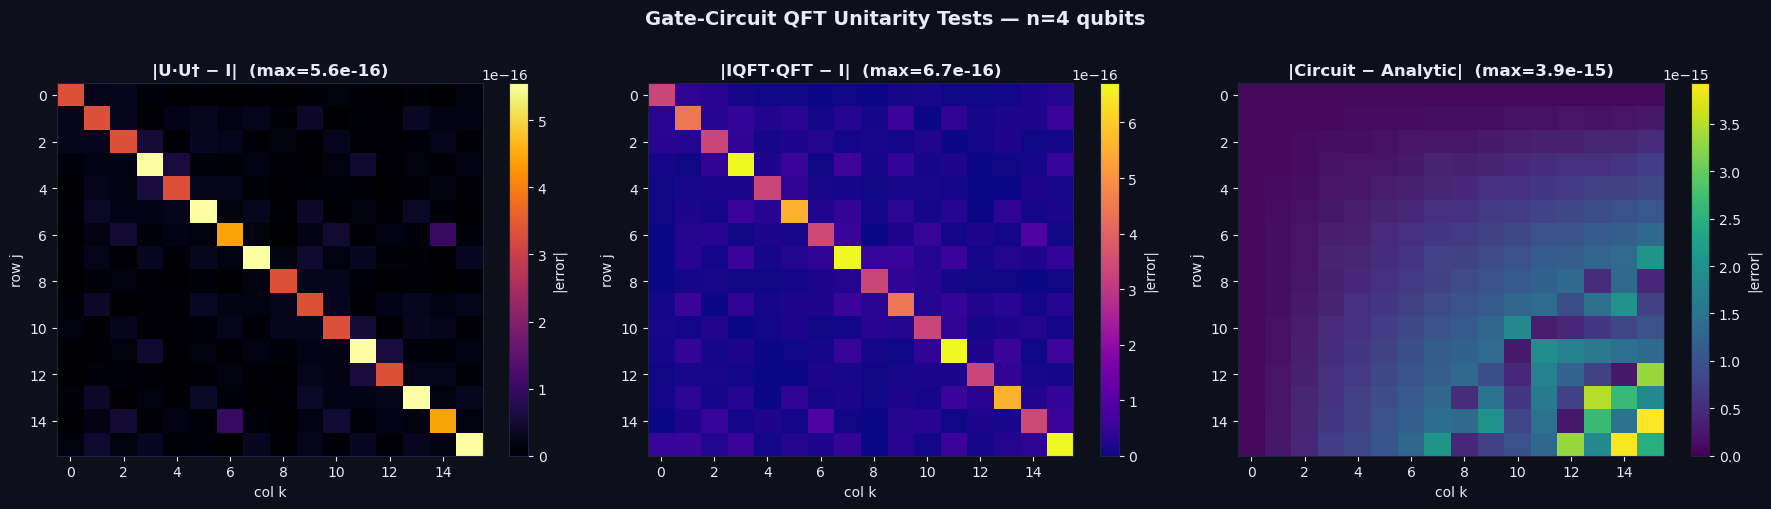

In [6]:
# Unitarity tests for n=3 and n=4
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
n_test = 4
Uc = qft_circuit(n_test)
Ui = iqft_circuit(n_test)
In = np.eye(2**n_test)

for ax_i, (data, cmap, title) in zip(axes, [
    (np.abs(Uc @ Uc.conj().T - In), 'inferno', f'|U·U† − I|  (max={np.max(np.abs(Uc@Uc.conj().T-In)):.1e})'),
    (np.abs(Ui @ Uc - In),          'plasma',  f'|IQFT·QFT − I|  (max={np.max(np.abs(Ui@Uc-In)):.1e})'),
    (np.abs(Uc - analytic_qft(n_test)), 'viridis', f'|Circuit − Analytic|  (max={np.max(np.abs(Uc-analytic_qft(n_test))):.1e})'),
]):
    im = ax_i.imshow(data, cmap=cmap, vmin=0, vmax=max(data.max(),1e-16),
                     interpolation='nearest', aspect='auto')
    plt.colorbar(im, ax=ax_i, label='|error|')
    ax_i.set_title(title, fontweight='bold', color=TEXT)
    ax_i.set_xlabel('col k'); ax_i.set_ylabel('row j')

plt.suptitle(f'Gate-Circuit QFT Unitarity Tests — n={n_test} qubits',
             fontsize=14, fontweight='bold', color=TEXT, y=1.01)
plt.tight_layout(); plt.show()


---
## 6. Pauli Decomposition of a 4×4 Matrix

Every $4\times 4$ Hermitian matrix lives in the 16-dimensional space spanned
by $\{I,X,Y,Z\}^{\otimes 2}$.  The decomposition coefficient is:

$$c_P = \frac{\text{Tr}(P^\dagger M)}{4}$$


In [7]:
# ── Pauli matrices ────────────────────────────────────────────────
I2 = np.eye(2, dtype=complex)
X  = np.array([[0,1],[1,0]], dtype=complex)
Y  = np.array([[0,-1j],[1j,0]], dtype=complex)
Z  = np.array([[1,0],[0,-1]], dtype=complex)
PAULIS = {'I':I2, 'X':X, 'Y':Y, 'Z':Z}

def pauli_tensor(labels):
    """Tensor product of Paulis: 'ZI' → Z⊗I."""
    r = PAULIS[labels[0]]
    for ch in labels[1:]: r = np.kron(r, PAULIS[ch])
    return r

def pauli_decompose(M):
    """Decompose 2^n × 2^n Hermitian M into Pauli basis."""
    dim = M.shape[0]; n = int(round(np.log2(dim)))
    coeffs = {}
    for labels in iproduct('IXYZ', repeat=n):
        label = ''.join(labels)
        P = pauli_tensor(label)
        c = np.trace(P.conj().T @ M) / dim
        if abs(c) > 1e-12: coeffs[label] = complex(c)
    return coeffs

def reconstruct_from_pauli(coeffs, n):
    M = np.zeros((2**n,2**n), dtype=complex)
    for label, c in coeffs.items(): M += c * pauli_tensor(label)
    return M

# Define the demo Hamiltonian
H = (1.5 * pauli_tensor('ZI') + 0.8 * pauli_tensor('IZ')
   + 0.4 * pauli_tensor('XX') + 0.3 * pauli_tensor('YY'))
H = H.real   # purely real symmetric

print("H =")
print(np.round(H, 4))

coeffs = pauli_decompose(H)
print("\nPauli decomposition:")
print(f"  {'Label':>6}   {'Re(c)':>10}   {'Im(c)':>10}   {'|c|':>8}")
print("  " + "─"*44)
for lbl, c in sorted(coeffs.items(), key=lambda x: -abs(x[1])):
    print(f"  {lbl:>6}   {c.real:>10.5f}   {c.imag:>10.5f}   {abs(c):>8.5f}")

H_rec = reconstruct_from_pauli(coeffs, n=2)
print(f"\nReconstruction error: {np.max(np.abs(H - H_rec)):.3e}")


H =
[[ 2.3  0.   0.   0.1]
 [ 0.   0.7  0.7  0. ]
 [ 0.   0.7 -0.7  0. ]
 [ 0.1  0.   0.  -2.3]]

Pauli decomposition:
   Label        Re(c)        Im(c)        |c|
  ────────────────────────────────────────────
      ZI      1.50000      0.00000    1.50000
      IZ      0.80000      0.00000    0.80000
      XX      0.40000      0.00000    0.40000
      YY      0.30000      0.00000    0.30000

Reconstruction error: 1.110e-16


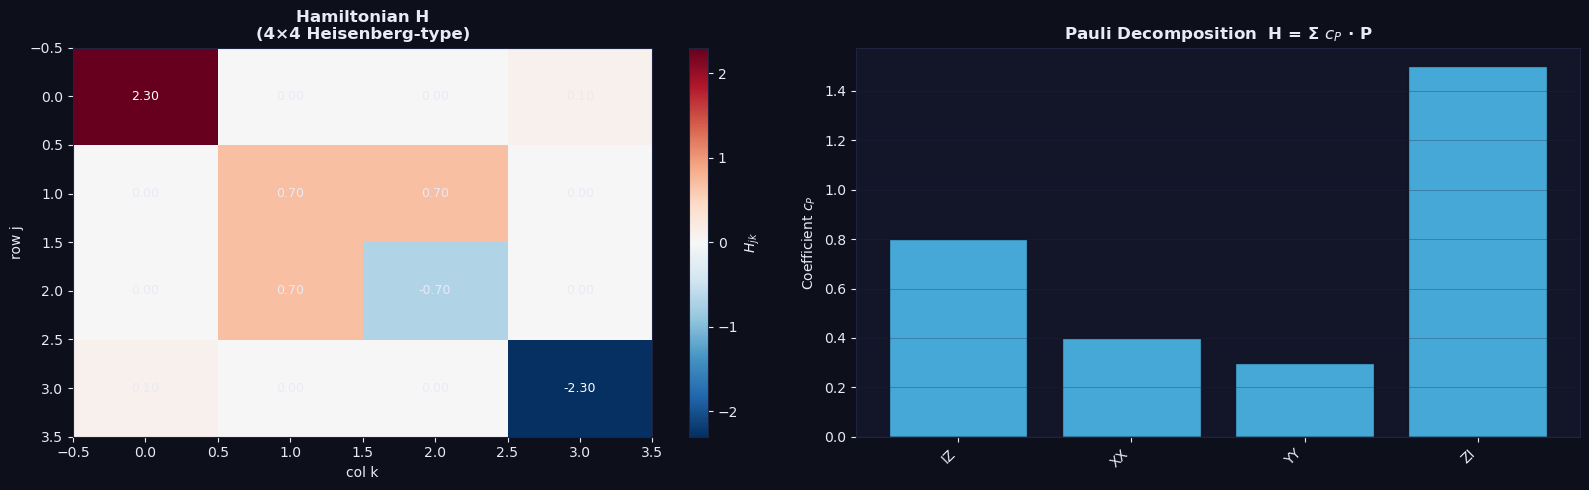

In [8]:
# Visualise Pauli coefficients and Hamiltonian
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Hamiltonian heatmap
ax = axes[0]
vabs = max(np.abs(H).max(), 1e-9)
im = ax.imshow(H, cmap='RdBu_r', vmin=-vabs, vmax=vabs,
               interpolation='nearest', aspect='auto')
plt.colorbar(im, ax=ax, label='$H_{jk}$')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{H[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color='white' if abs(H[i,j])>vabs*0.4 else TEXT)
ax.set_title('Hamiltonian H\n(4×4 Heisenberg-type)',
             fontweight='bold', color=TEXT)
ax.set_xlabel('col k'); ax.set_ylabel('row j')

# Right: Pauli bar chart
ax2 = axes[1]
lbls = list(coeffs.keys()); vals = [coeffs[l].real for l in lbls]
cols = [ACCENT if v>=0 else WARM for v in vals]
ax2.bar(range(len(lbls)), vals, color=cols, edgecolor=BG, alpha=0.85)
ax2.set_xticks(range(len(lbls))); ax2.set_xticklabels(lbls, rotation=45, ha='right')
ax2.axhline(0, color=GRID, lw=1)
ax2.set_title('Pauli Decomposition  H = Σ $c_P$ · P',
              fontweight='bold', color=TEXT)
ax2.set_ylabel('Coefficient $c_P$')
ax2.grid(True, alpha=0.35, axis='y')
plt.tight_layout(); plt.show()


---
## 7. Quantum Phase Estimation Algorithm

### Circuit

```
ancilla q_0  |0⟩ ──H──●──────────── ... ── IQFT_t ── measure
ancilla q_1  |0⟩ ──H────●────────── ... ── IQFT_t ── measure
  ...
ancilla q_{t-1} |0⟩ ──H──────────●  ... ── IQFT_t ── measure
target   |ψ⟩  ──────U^1──U^2──U^4 ... ─────────────── (discard)
```

Each ancilla qubit $k$ controls $U^{2^k}$ on the target.
After IQFT, measuring the ancilla gives integer $\tilde{j}$ with
$\varphi \approx \tilde{j}/2^t$.

### Phase convention

Since QPE returns $\varphi \in [0,1)$ but eigenvalues of $H$ can be
negative, we unwrap:
$$\lambda = \begin{cases} 2\pi\varphi/t_0 & \varphi \leq 0.5 \\ 2\pi(\varphi-1)/t_0 & \varphi > 0.5 \end{cases}$$


In [9]:
def matrix_exponentiate(H, t=1.0):
    """U = exp(i H t) via eigendecomposition."""
    vals, vecs = eigh(H)
    return (vecs * np.exp(1j*vals*t)) @ vecs.conj().T

def embed_anc_gate(n_anc, n_tgt, anc_qubit, gate2):
    """Embed 2×2 gate on ancilla qubit into (n_anc+n_tgt)-qubit space."""
    n_total = n_anc + n_tgt
    ops = [np.eye(2,dtype=complex)]*n_total; ops[anc_qubit]=gate2
    r=ops[0]
    for op in ops[1:]: r=np.kron(r,op)
    return r

def controlled_unitary(U_tgt, n_anc, anc_qubit, n_tgt):
    """Controlled-U: ancilla qubit `anc_qubit` controls U on target."""
    P0=np.array([[1,0],[0,0]],dtype=complex)
    P1=np.array([[0,0],[0,1]],dtype=complex)
    def anc_embed(proj):
        ops=[np.eye(2,dtype=complex)]*n_anc; ops[anc_qubit]=proj
        r=ops[0]
        for op in ops[1:]: r=np.kron(r,op)
        return r
    dim_tgt = 2**n_tgt
    return (np.kron(anc_embed(P0), np.eye(dim_tgt,dtype=complex))
          + np.kron(anc_embed(P1), U_tgt))

def qpe_circuit(U, eigenstate, n_phase):
    """
    Simulate QPE and return measurement probability distribution.

    Parameters
    ----------
    U          : m×m unitary (m = 2^n_tgt)
    eigenstate : length-m eigenvector of U
    n_phase    : number of ancilla qubits (precision = 1/2^n_phase)

    Returns
    -------
    probs : length-2^n_phase array of ancilla measurement probabilities
    """
    n_tgt   = int(round(np.log2(len(eigenstate))))
    dim_anc = 2**n_phase; dim_tgt = 2**n_tgt

    # Initialise |0...0>_anc ⊗ |ψ>_tgt
    anc0 = np.zeros(dim_anc, dtype=complex); anc0[0]=1.0
    psi  = np.kron(anc0, eigenstate.astype(complex))

    # H on every ancilla qubit
    for k in range(n_phase):
        psi = embed_anc_gate(n_phase, n_tgt, k, _H()) @ psi

    # Controlled-U^{2^k}
    Upow = U.copy()
    for k in range(n_phase-1, -1, -1):
        CU  = controlled_unitary(Upow, n_phase, k, n_tgt)
        psi = CU @ psi
        Upow = Upow @ Upow

    # IQFT on ancilla register
    IQFT_full = np.kron(iqft_circuit(n_phase), np.eye(dim_tgt,dtype=complex))
    psi = IQFT_full @ psi

    # Partial trace over target → ancilla probabilities
    return np.sum(np.abs(psi.reshape(dim_anc, dim_tgt))**2, axis=1)

print("QPE functions defined.")
print("Controlled-unitary test:")
U_test = analytic_qft(2)
CU     = controlled_unitary(U_test, 1, 0, 2)
print(f"  CU shape: {CU.shape},  max|CU·CU†−I|={np.max(np.abs(CU@CU.conj().T-np.eye(8))):.2e}")


QPE functions defined.
Controlled-unitary test:
  CU shape: (8, 8),  max|CU·CU†−I|=1.17e-16


---
## 8. QPE Example: Eigenvalues of the 4×4 Hamiltonian

We use $U = e^{iHt}$ with $t=1$ and run QPE with $n_{\rm phase}=6$
ancilla qubits (precision $\approx 2\pi/64 \approx 0.098$).


In [10]:
n_phase = 6
t       = 1.0
U       = matrix_exponentiate(H, t=t)

# Verify U is unitary
print(f"max|U·U†−I| = {np.max(np.abs(U@U.conj().T-np.eye(4))):.2e}")

# Exact eigenvalues and phases
exact_evals, exact_evecs = eigh(H)
exact_phases = (exact_evals * t / (2*np.pi)) % 1.0

print(f"\nExact eigenvalues and QPE phases (n_phase={n_phase}):")
print(f"  {'k':>3}  {'λ_k':>10}  {'φ_k':>10}  {'j_ideal':>12}")
print("  " + "─"*42)
for k, (ev, ph) in enumerate(zip(exact_evals, exact_phases)):
    print(f"  {k:>3}  {ev:>10.5f}  {ph:>10.6f}  {ph*2**n_phase:>12.3f}")


max|U·U†−I| = 2.23e-16

Exact eigenvalues and QPE phases (n_phase=6):
    k         λ_k         φ_k       j_ideal
  ──────────────────────────────────────────
    0    -2.30217    0.633598        40.550
    1    -0.98995    0.842445        53.916
    2     0.98995    0.157555        10.084
    3     2.30217    0.366402        23.450


In [11]:
# Run QPE for each eigenstate
results = []
for k in range(4):
    evec  = exact_evecs[:, k]
    probs = qpe_circuit(U, evec, n_phase)
    best  = int(np.argmax(probs))
    phi_raw = best / 2**n_phase
    phi_qpe = phi_raw - 1.0 if phi_raw > 0.5 else phi_raw
    lam_qpe = phi_qpe * 2*np.pi / t
    results.append(dict(k=k, exact_eval=exact_evals[k],
                        exact_phase=exact_phases[k],
                        phi_raw=phi_raw, phi_qpe=phi_qpe,
                        lam_qpe=lam_qpe,
                        error=abs(lam_qpe-exact_evals[k]),
                        confidence=float(probs[best]),
                        probs=probs))

print(f"QPE Results (n_phase={n_phase}, dim_anc={2**n_phase}):")
print(f"  {'k':>3}  {'λ_exact':>10}  {'φ_exact':>10}  "
      f"{'φ_QPE':>10}  {'λ_QPE':>10}  {'|error|':>10}  conf")
print("  " + "─"*70)
for r in results:
    print(f"  {r['k']:>3}  {r['exact_eval']:>10.5f}  {r['exact_phase']:>10.6f}  "
          f"{r['phi_qpe']:>10.6f}  {r['lam_qpe']:>10.5f}  "
          f"{r['error']:>10.2e}  {r['confidence']:.4f}")


QPE Results (n_phase=6, dim_anc=64):
    k     λ_exact     φ_exact       φ_QPE       λ_QPE     |error|  conf
  ──────────────────────────────────────────────────────────────────────
    0    -2.30217    0.633598   -0.359375    -2.25802    4.42e-02  0.4886
    1    -0.98995    0.842445   -0.156250    -0.98175    8.20e-03  0.9773
    2     0.98995    0.157555    0.156250     0.98175    8.20e-03  0.9773
    3     2.30217    0.366402    0.359375     2.25802    4.42e-02  0.4886


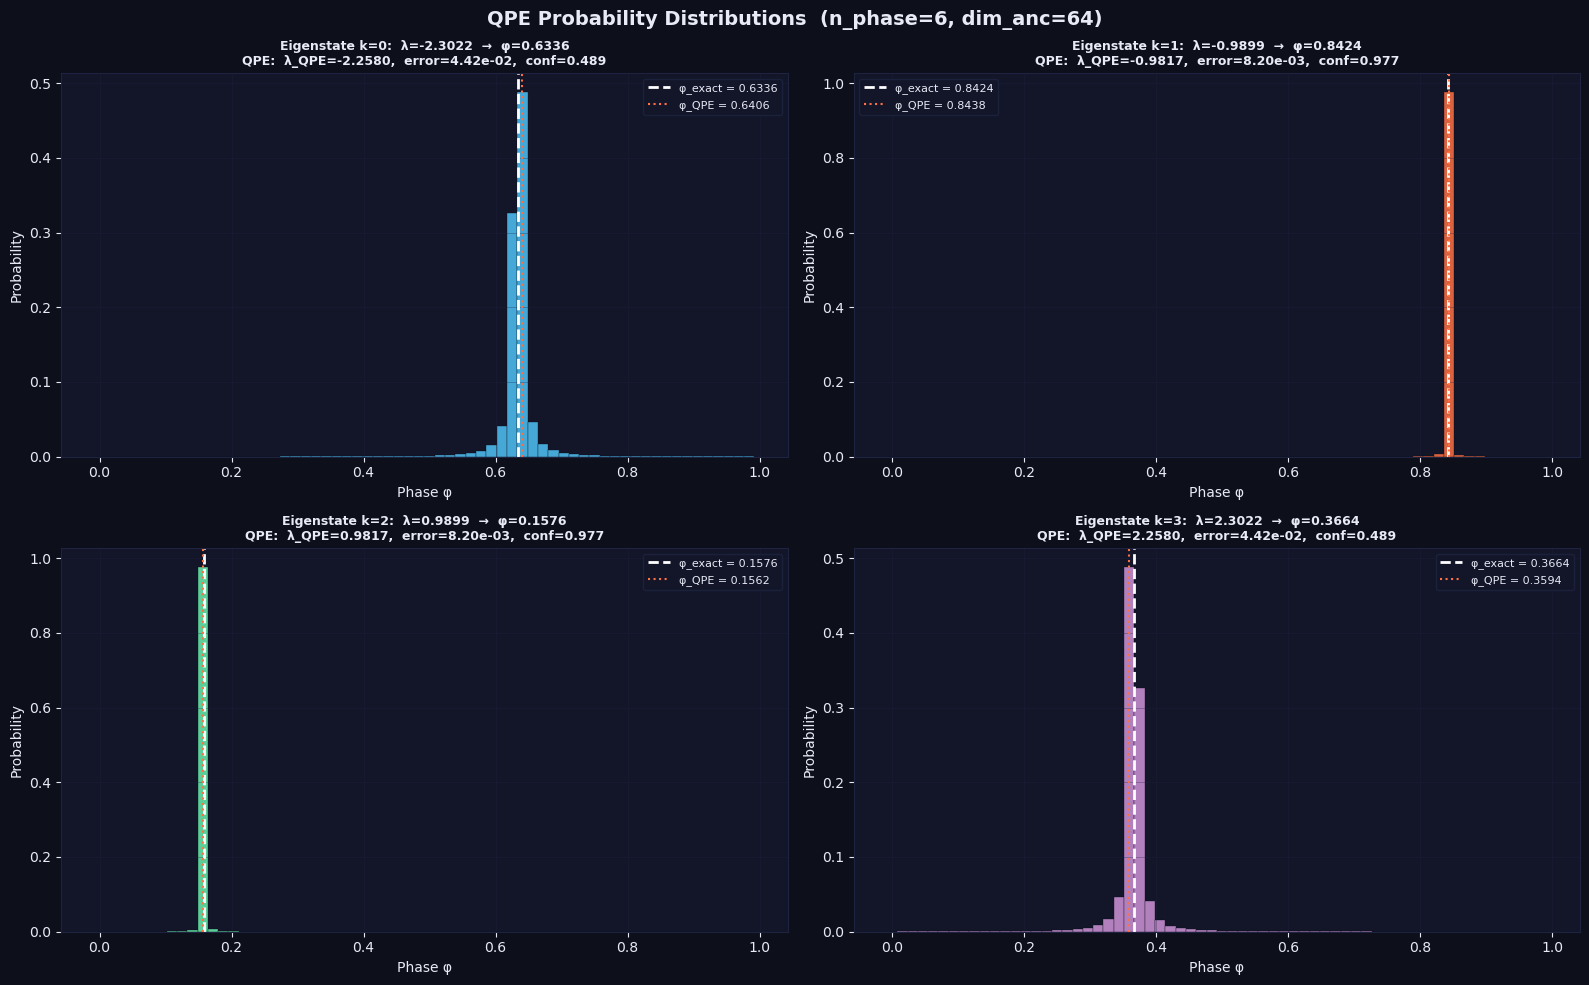

In [12]:
# ── Plot probability distributions ───────────────────────────────
dim_anc    = 2**n_phase
phase_axis = np.arange(dim_anc) / dim_anc
ev_colours = [ACCENT, WARM, GREEN, PURPLE]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for k, r in enumerate(results):
    ax = axes[k]
    ax.bar(phase_axis, r['probs'], width=1/dim_anc,
           color=ev_colours[k], alpha=0.85, edgecolor=BG, linewidth=0.3)
    ax.axvline(r['exact_phase'], color='white', lw=2.0, ls='--',
               label=f"φ_exact = {r['exact_phase']:.4f}")
    ax.axvline(r['phi_raw'], color=WARM, lw=1.5, ls=':',
               label=f"φ_QPE = {r['phi_raw']:.4f}")
    ax.set_title(f"Eigenstate k={k}:  λ={r['exact_eval']:.4f}  "
                 f"→  φ={r['exact_phase']:.4f}\n"
                 f"QPE:  λ_QPE={r['lam_qpe']:.4f},  error={r['error']:.2e},  "
                 f"conf={r['confidence']:.3f}",
                 fontweight='bold', color=TEXT, fontsize=9)
    ax.set_xlabel("Phase φ", fontsize=10); ax.set_ylabel("Probability", fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.35)

plt.suptitle(f'QPE Probability Distributions  (n_phase={n_phase}, dim_anc={dim_anc})',
             fontsize=14, fontweight='bold', color=TEXT)
plt.tight_layout(); plt.show()


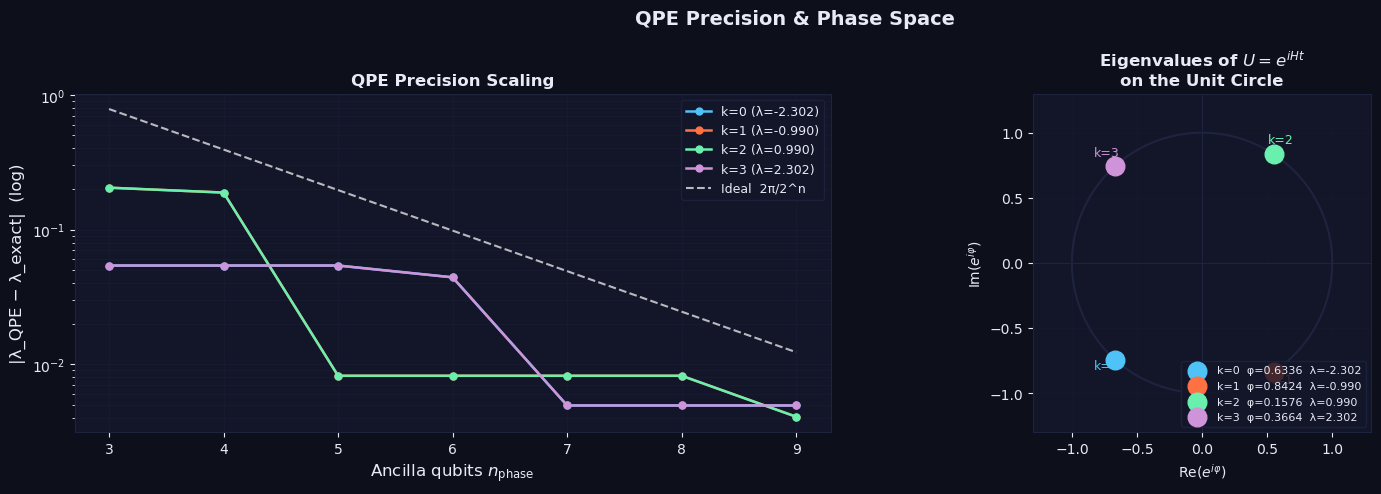

In [14]:
# ── Precision scaling ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

n_range = range(3, 10)
for i_k in range(4):
    errs = []
    for n_p in n_range:
        U_l = matrix_exponentiate(H, t=1.0)
        pr  = qpe_circuit(U_l, exact_evecs[:,i_k], n_p)
        phi_r = int(np.argmax(pr)) / (2**n_p)
        phi_u = phi_r-1.0 if phi_r>0.5 else phi_r
        errs.append(abs(phi_u*2*np.pi - exact_evals[i_k]))
    ax1.semilogy(list(n_range), errs, 'o-', color=ev_colours[i_k], lw=1.8, ms=5,
                  label=f"k={i_k} (λ={exact_evals[i_k]:.3f})")

# Ideal 1/2^n scaling
n_arr = np.array(list(n_range), float)
ax1.semilogy(n_arr, 2*np.pi/2**n_arr, '--', color='white', lw=1.5, alpha=0.7,
              label='Ideal  2π/2^n')
ax1.set_xlabel("Ancilla qubits $n_{\\rm phase}$", fontsize=12)
ax1.set_ylabel("|λ_QPE − λ_exact|  (log)", fontsize=12)
ax1.set_title("QPE Precision Scaling", fontweight='bold', color=TEXT)
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.35, which='both')

# Unit circle plot
th = np.linspace(0, 2*np.pi, 400)
ax2.plot(np.cos(th), np.sin(th), color=GRID, lw=1.5)
for i_k, (ev, ph) in enumerate(zip(exact_evals, exact_phases)):
    angle = 2*np.pi*ph
    ax2.scatter(np.cos(angle), np.sin(angle), s=180,
                 color=ev_colours[i_k], zorder=5,
                 label=f"k={i_k}  φ={ph:.4f}  λ={ev:.3f}")
    ax2.annotate(f"k={i_k}", (np.cos(angle)*1.10, np.sin(angle)*1.10),
                  color=ev_colours[i_k], fontsize=9, ha='center')
ax2.axhline(0,color=GRID,lw=0.8); ax2.axvline(0,color=GRID,lw=0.8)
ax2.set_xlim(-1.3,1.3); ax2.set_ylim(-1.3,1.3); ax2.set_aspect('equal')
ax2.set_title("Eigenvalues of $U = e^{iHt}$\non the Unit Circle",
               fontweight='bold', color=TEXT)
ax2.set_xlabel("Re($e^{i\\varphi}$)"); ax2.set_ylabel("Im($e^{i\\varphi}$)")
ax2.legend(fontsize=8, loc='lower right'); ax2.grid(True, alpha=0.25)

plt.suptitle("QPE Precision & Phase Space", fontsize=14,
             fontweight='bold', color=TEXT)
plt.tight_layout(); plt.show()


---
## 9. Summary & Key Formulae

### Formulae

| Quantity | Formula |
|:---------|:--------|
| QFT matrix | $F_{jk} = e^{2\pi i jk/2^n}/\sqrt{2^n}$ |
| Hadamard | $H = (\vert 0\rangle + \vert 1\rangle)\langle 0\vert/\sqrt{2} + (\vert 0\rangle - \vert 1\rangle)\langle 1\vert/\sqrt{2}$ |
| Phase gate | $R_k = \text{diag}(1,\, e^{2\pi i/2^k})$ |
| QFT gate count | $n$ H $+$ $n(n-1)/2$ CR $+$ $\lfloor n/2\rfloor$ SWAP |
| Pauli coefficient | $c_P = \text{Tr}(P^\dagger H)/2^n$ |
| QPE phase | $\varphi \approx \tilde{j}/2^t$ |
| QPE eigenvalue | $\lambda = 2\pi\varphi/t_0$ (unwrap if $\varphi > 0.5$) |
| QPE precision | $\vert\varphi - \tilde{j}/2^t\vert \leq 1/2^t$ |

### QPE Results Summary


In [15]:
print("=" * 62)
print(f"  QPE Summary  (n_phase={n_phase},  t={t})")
print("=" * 62)
print(f"  Hamiltonian: H = 1.5·ZI + 0.8·IZ + 0.4·XX + 0.3·YY")
print(f"  Precision:   2π/2^{n_phase} = {2*np.pi/2**n_phase:.5f}")
print()
print(f"  {'k':>3}  {'λ_exact':>10}  {'λ_QPE':>10}  {'|error|':>10}  {'conf':>6}")
print("  " + "─"*46)
for r in results:
    print(f"  {r['k']:>3}  {r['exact_eval']:>10.5f}  "
          f"{r['lam_qpe']:>10.5f}  {r['error']:>10.2e}  {r['confidence']:>6.4f}")
print()
print("  Pauli decomposition of H:")
for lbl, c in sorted(coeffs.items(), key=lambda x:-abs(x[1])):
    print(f"    {lbl}: {c.real:+.3f}")


  QPE Summary  (n_phase=6,  t=1.0)
  Hamiltonian: H = 1.5·ZI + 0.8·IZ + 0.4·XX + 0.3·YY
  Precision:   2π/2^6 = 0.09817

    k     λ_exact       λ_QPE     |error|    conf
  ──────────────────────────────────────────────
    0    -2.30217    -2.25802    4.42e-02  0.4886
    1    -0.98995    -0.98175    8.20e-03  0.9773
    2     0.98995     0.98175    8.20e-03  0.9773
    3     2.30217     2.25802    4.42e-02  0.4886

  Pauli decomposition of H:
    ZI: +1.500
    IZ: +0.800
    XX: +0.400
    YY: +0.300


### References

- Nielsen & Chuang, *Quantum Computation and Quantum Information* (2000)
- Kitaev, A., *Quantum measurements and the Abelian Stabilizer Problem* (1995)
- Cleve et al., *Quantum algorithms revisited*, Proc. R. Soc. A **454** (1998)
